In [22]:
import numpy as np
import torch
from torch.utils.data import DataLoader
from sklearn.metrics import (classification_report, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
from pathlib import Path

from brainvision.constants import *
from brainvision.models import (Baseline1DDNN, FabeloDNN, Fabelo2DCNN,
                                 HuEtAl1DCNN, LeeEtAl2DCNN,
                                 HamidaEtAl3DCNN, HybridSN, SpectralFormer)
from brainvision.data import HSIPixelDataset, HSIPatchDataset
from brainvision.data.io import load_all_campaigns
from brainvision.validation import get_splits
from brainvision.utils import build_run_name
from brainvision.metrics import (compute_metrics, aggregate_fold_metrics,
                                  print_metrics, print_aggregate)
from brainvision.history import plot_history_curves, load_history
from brainvision.device import get_device, print_device_info, empty_device_cache

In [23]:
device = get_device()
print_device_info(device)

  Device     : MPS
  Name       : Apple Silicon (MPS)
  Memory     : 19,070 MB total  | N/A free  | N/A used


In [24]:
# ══════════════════════════════════════════════════════════════════════════════
#                        CONFIGURE EXPERIMENT HERE
# ══════════════════════════════════════════════════════════════════════════════

MODEL    = "SpectralFormer"      # "1D-NN" | "1D-NN-Fabelo" | "1D-CNN" | "2D-CNN" | "3D-CNN" | "SpectralFormer"
LOSS_FN  = "CE"                 # "CE" | "FL" | "DL" | "UFL"
REDUCE_PIXELS = True            # apply K-Means reduction to training set

STRATEGY = "vp_fabelo"          # "vp1" | "vp2" | "vp3" | "lopo" | "vp_fabelo"
N_FOLDS  = 5                    # used for vp3 and lopo only; vp_fabelo always uses 5 folds

In [25]:
PATCH_MODELS = {'2D-CNN', '2D-CNN-Fabelo', '3D-CNN', 'HybridSN'}

MODEL_REGISTRY = {
    '1D-NN'         : lambda: Baseline1DDNN(N_DECIMATED_BANDS, N_CLASSES,
                                             dropout=True,
                                             dropout_rate=DROPOUT_RATE),
    '1D-NN-Fabelo'  : lambda: FabeloDNN(N_DECIMATED_BANDS, N_CLASSES),
    '1D-CNN'        : lambda: HuEtAl1DCNN(N_DECIMATED_BANDS, N_CLASSES),
    '2D-CNN'        : lambda: LeeEtAl2DCNN(N_DECIMATED_BANDS, N_CLASSES,
                                             PATCH_SIZE),
    '2D-CNN-Fabelo' : lambda: Fabelo2DCNN(N_DECIMATED_BANDS, N_CLASSES,
                                         PATCH_SIZE),
    '3D-CNN'        : lambda: HamidaEtAl3DCNN(N_DECIMATED_BANDS, N_CLASSES,
                                               PATCH_SIZE),
    'HybridSN'      : lambda: HybridSN(N_DECIMATED_BANDS, PATCH_SIZE,
                                        N_CLASSES),
    'SpectralFormer': lambda: SpectralFormer(N_DECIMATED_BANDS, N_CLASSES,
                                              near_band    = SF_NEAR_BAND,
                                              dim          = SF_DIM,
                                              depth        = SF_DEPTH,
                                              heads        = SF_HEADS,
                                              dim_head     = SF_DIM_HEAD,
                                              mlp_dim      = SF_MLP_DIM,
                                              dropout      = SF_DROPOUT,
                                              emb_dropout  = SF_EMB_DROPOUT,
                                              mode         = SF_MODE),
}

In [26]:
campaigns = load_all_campaigns(PROCESSED_DIRS)

Campaigns loaded from memory cache (61 patients across 3 campaigns)


In [27]:
all_splits = get_splits(campaigns, STRATEGY)


════════════════════════════════════════════════════════════
  Training Curves — SpectralFormer × CE × vp_fabelo
════════════════════════════════════════════════════════════


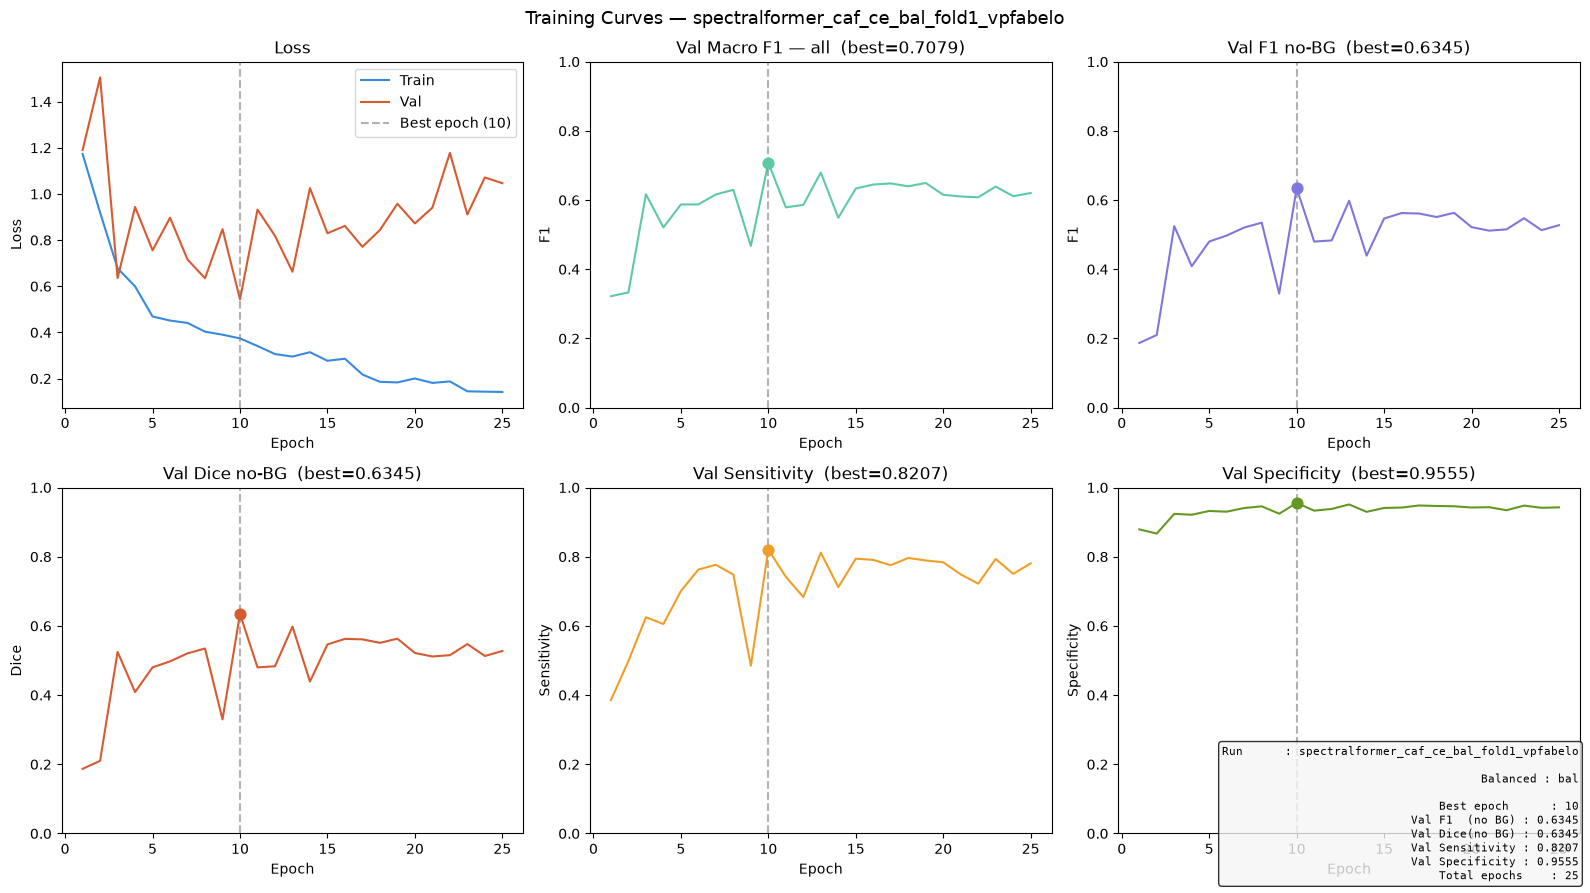

  Saved → ../results/spectralformer_caf_ce_bal_fold1_vpfabelo_curves.png


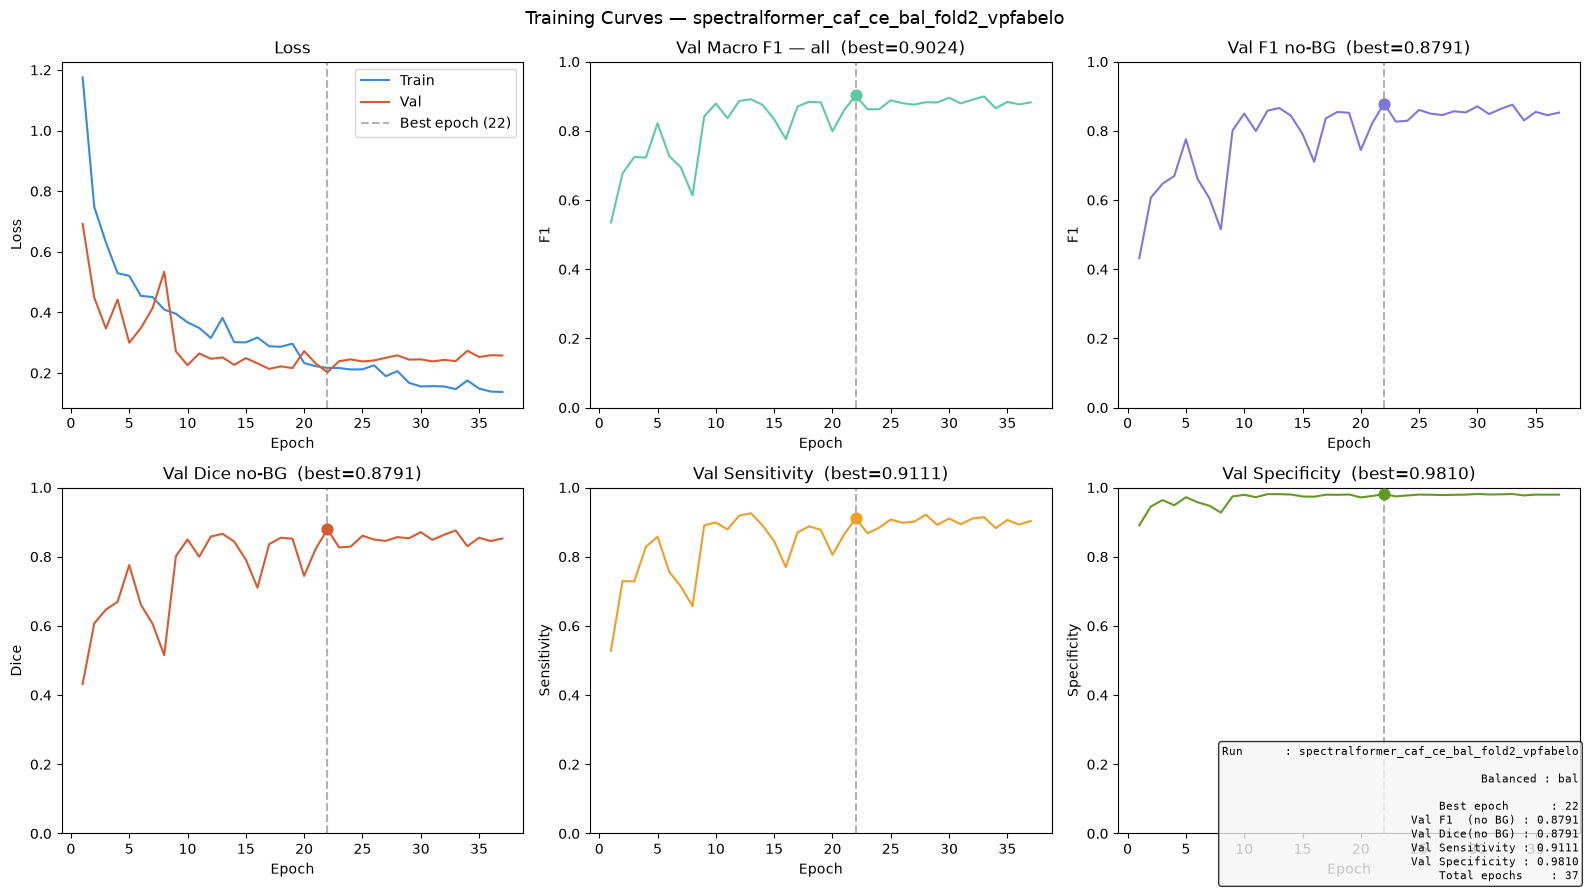

  Saved → ../results/spectralformer_caf_ce_bal_fold2_vpfabelo_curves.png


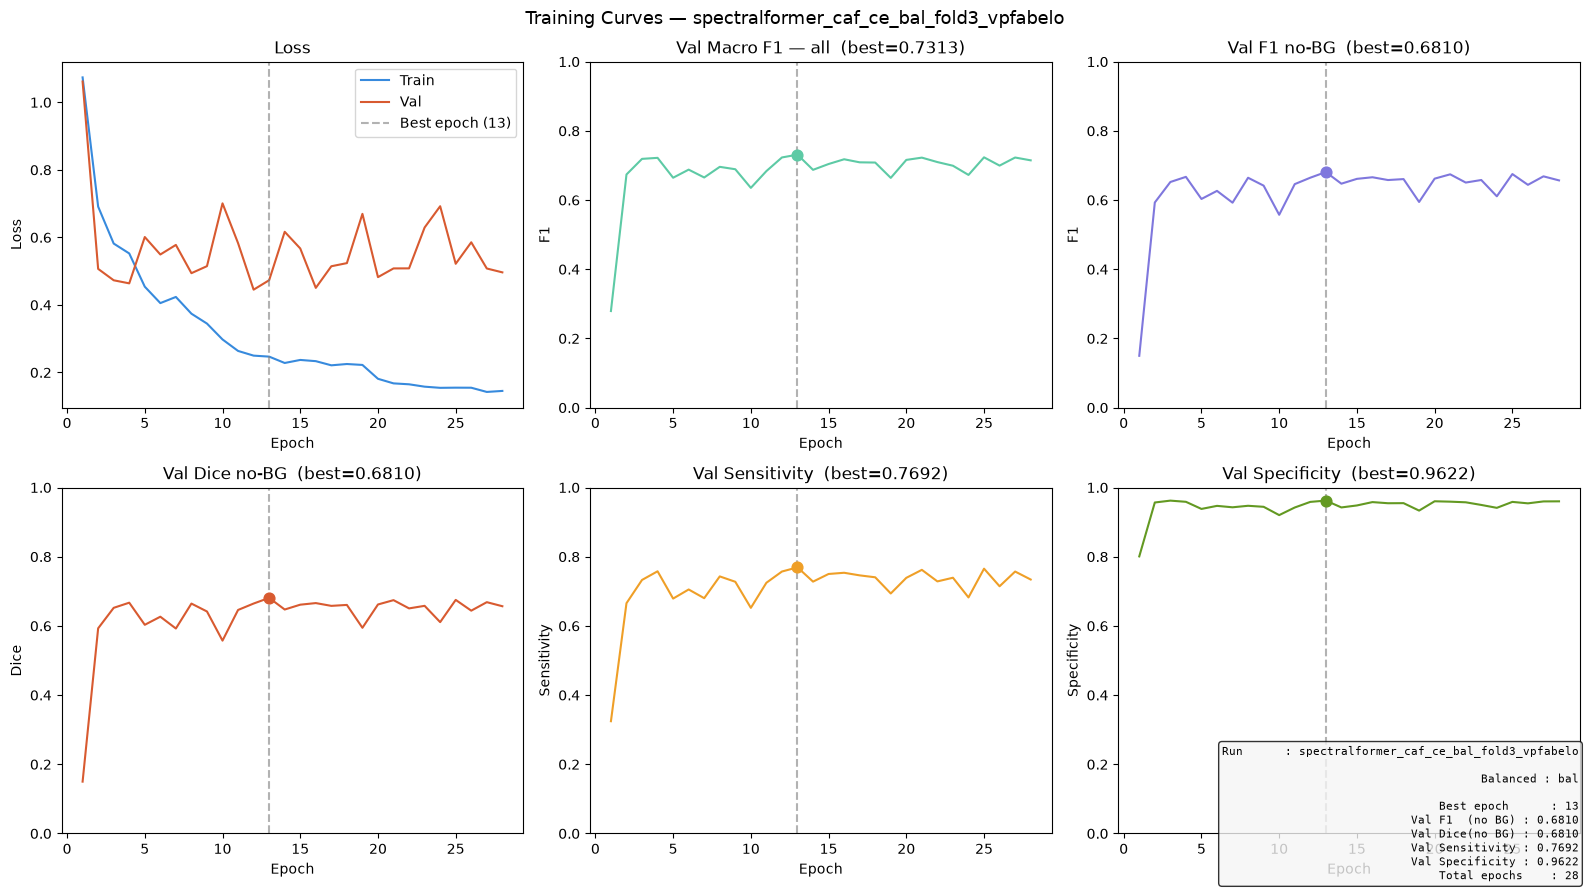

  Saved → ../results/spectralformer_caf_ce_bal_fold3_vpfabelo_curves.png


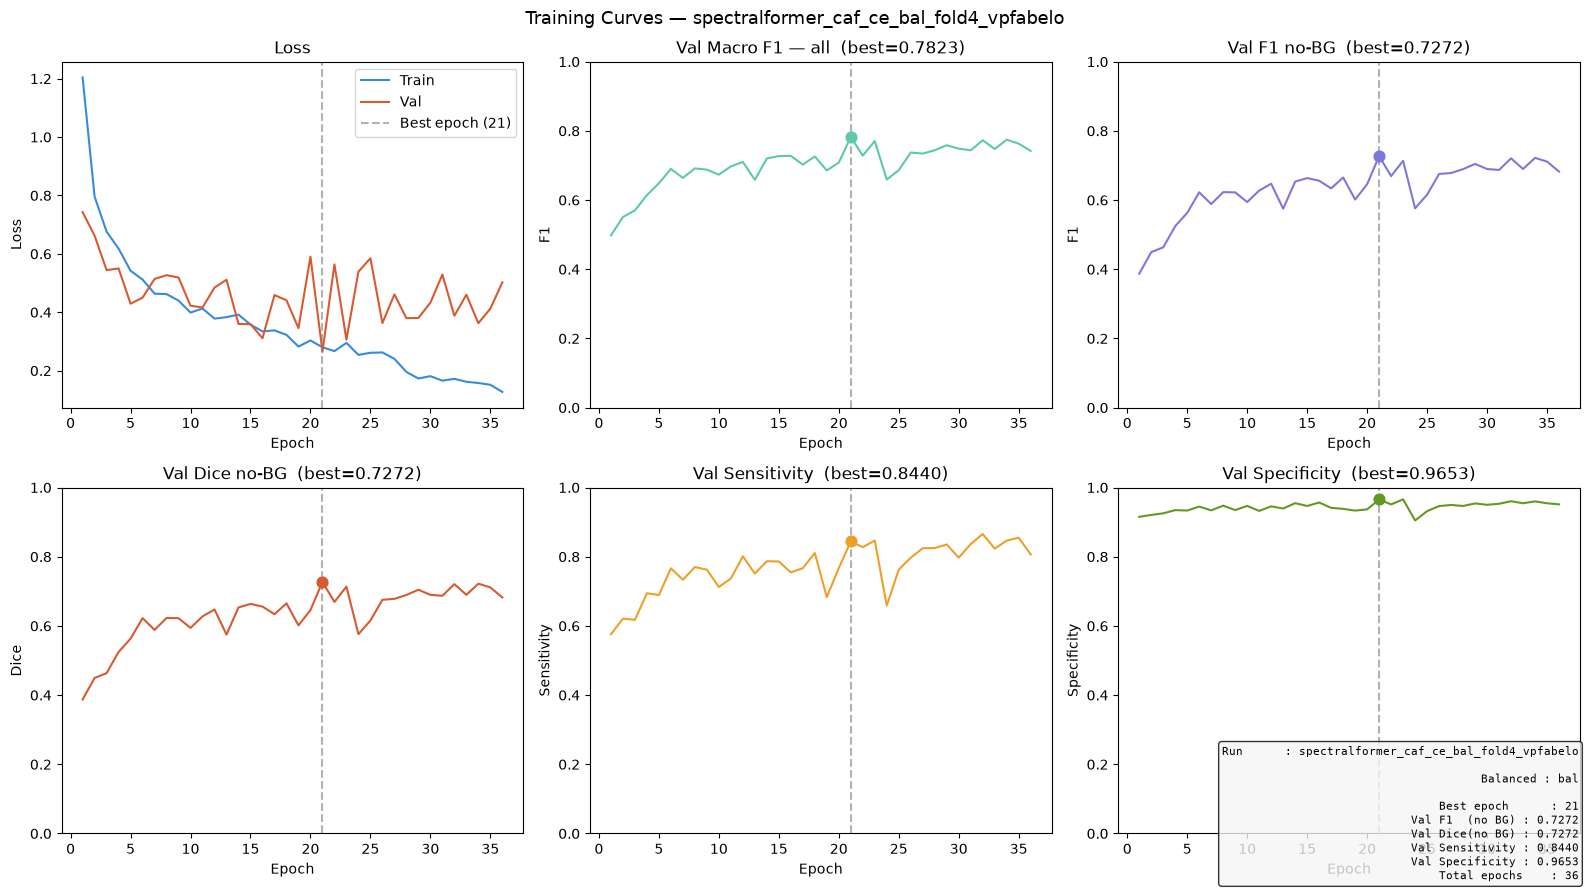

  Saved → ../results/spectralformer_caf_ce_bal_fold4_vpfabelo_curves.png


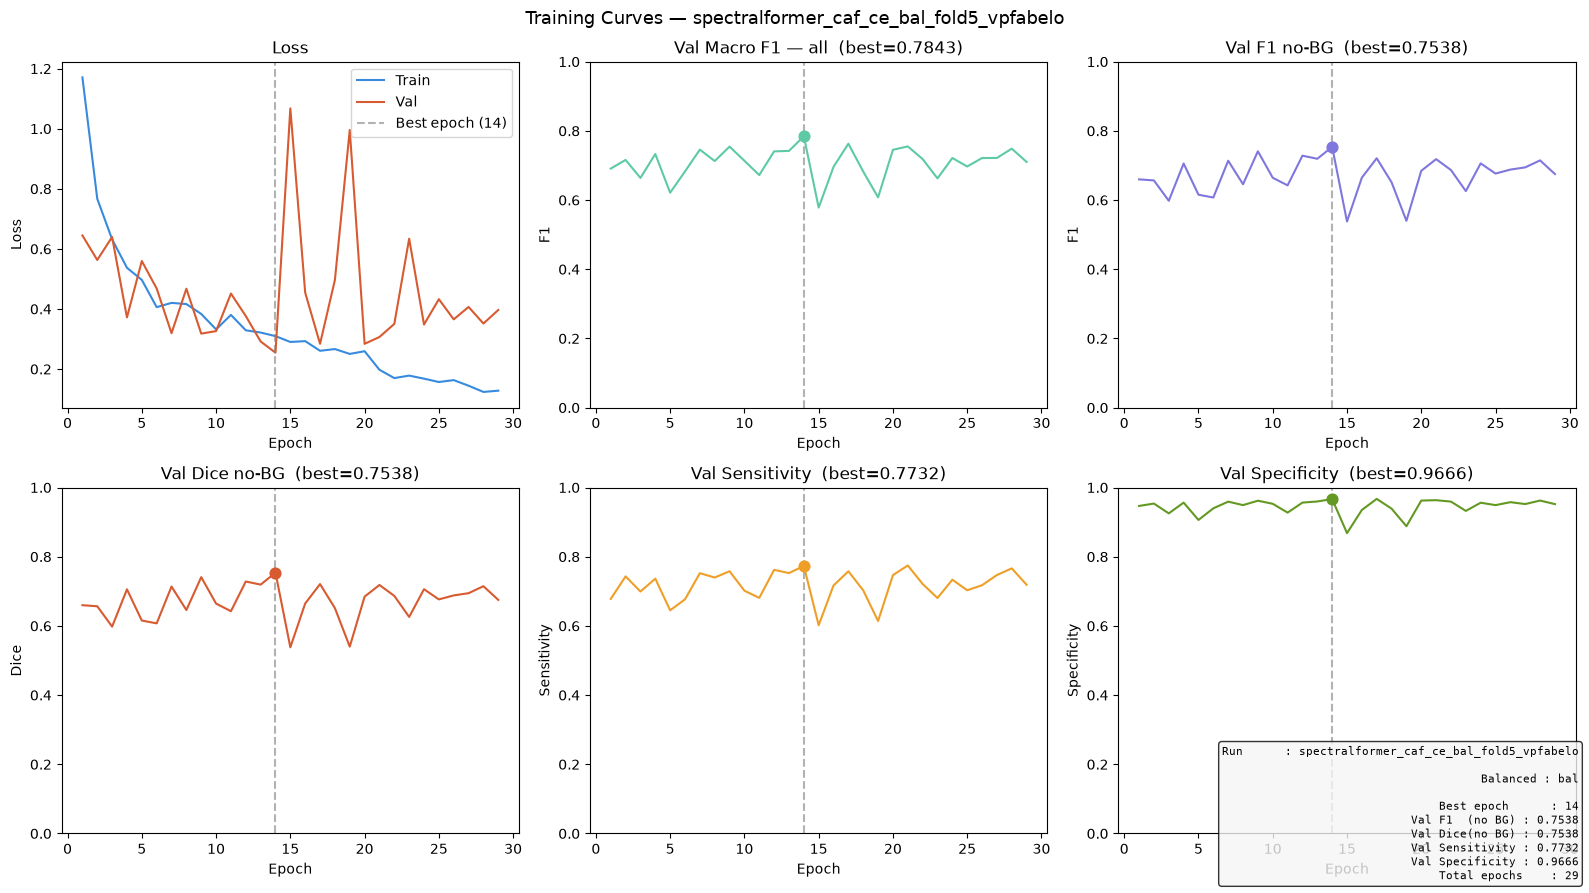

  Saved → ../results/spectralformer_caf_ce_bal_fold5_vpfabelo_curves.png


In [28]:
print(f"\n{'═'*60}")
print(f"  Training Curves — {MODEL} × {LOSS_FN} × {STRATEGY}")
print(f"{'═'*60}")

for split in all_splits:
    cfg = {
        "model": MODEL,
        "loss": LOSS_FN,
        "reduce_pixels": REDUCE_PIXELS,
        "strategy": STRATEGY,
        "fold": split["fold"],
        "sf_mode": SF_MODE
    }
    run_name = build_run_name(
        model         = cfg['model'],
        loss_fn       = cfg['loss'],
        strategy      = cfg['strategy'],
        fold          = cfg['fold'],
        reduce_pixels = cfg['reduce_pixels'],
        sf_mode       = cfg['sf_mode']
    )
    history  = load_history(cfg, RESULTS_DIR)
    if history:
        plot_history_curves(history, run_name, RESULTS_DIR)

In [29]:
@torch.no_grad()
def predict(model, loader) -> tuple[np.ndarray, np.ndarray]:
    model.eval()
    all_preds, all_targets = [], []
    for X, y in loader:
        X      = X.to(device)
        logits = model(X)
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_targets.extend(y.numpy())
    return np.array(all_preds), np.array(all_targets)


def plot_confusion_matrix(metrics: dict):
    cm   = metrics['confusion_matrix']
    cm_n = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-6)

    fig, ax = plt.subplots(figsize=(6, 5))
    disp    = ConfusionMatrixDisplay(
        confusion_matrix = cm_n,
        display_labels   = [CLASS_NAMES_SHORT[i+1] for i in range(N_CLASSES)]
    )
    disp.plot(ax=ax, colorbar=True, cmap='Blues', values_format='.2f')
    ax.set_title(f"Confusion Matrix — {metrics['run_name']}")
    plt.tight_layout()
    plt.savefig(f"{RESULTS_DIR}/{metrics['run_name']}_cm.png",
                dpi=150, bbox_inches='tight')
    plt.show()


def build_test_loader(split: dict) -> DataLoader:
    """Build test DataLoader — always unbalanced, never augmented."""
    test_patients = split['test']
    if MODEL in PATCH_MODELS:
        test_dataset = HSIPatchDataset(
            test_patients,
            patch_size = PATCH_SIZE,
            balance    = False,
            augment    = False,
        )
    else:
        test_dataset = HSIPixelDataset(test_patients)
    return DataLoader(test_dataset, batch_size=BATCH_SIZE,
                      shuffle=False, num_workers=0, pin_memory=True)

In [30]:
def evaluate_fold(split: dict) -> dict | None:
    cfg = {
        "model": MODEL,
        "loss": LOSS_FN,
        "reduce_pixels": REDUCE_PIXELS,
        "strategy": STRATEGY,
        "fold": split["fold"],
        "sf_mode": SF_MODE
    }
    run_name = build_run_name(
        model         = cfg['model'],
        loss_fn       = cfg['loss'],
        strategy      = cfg['strategy'],
        fold          = cfg['fold'],
        reduce_pixels = cfg['reduce_pixels'],
        sf_mode       = cfg['sf_mode']
    )
    checkpoint_path = Path(CHECKPOINTS_DIR) / f"{run_name}.pt"

    if not checkpoint_path.exists():
        print(f"  ⚠️  Checkpoint not found: {checkpoint_path}")
        return None

    print(f"\n{'─'*60}")
    print(f"  Evaluating : {run_name}")
    if 'val_patient' in split:
        print(f"  Val patient: {split['val_patient']}")
    print(f"  Test images: {len(split['test'])}")
    print(f"{'─'*60}")

    test_loader = build_test_loader(split)

    model = MODEL_REGISTRY[MODEL]().to(device)
    model.load_state_dict(
        torch.load(checkpoint_path, map_location=device, weights_only=True)
    )

    preds, targets = predict(model, test_loader)
    metrics        = compute_metrics(targets, preds, run_name)

    print_metrics(metrics)
    plot_confusion_matrix(metrics)

    print(classification_report(
        targets, preds,
        target_names = [CLASS_NAMES[i+1] for i in range(N_CLASSES)],
        digits=4, zero_division=0
    ))

    np.save(f"{RESULTS_DIR}/{run_name}_test_metrics.npy", metrics)
    print(f"  Saved → {RESULTS_DIR}/{run_name}_test_metrics.npy")

    del model
    empty_device_cache()

    return metrics


────────────────────────────────────────────────────────────
  Evaluating : spectralformer_caf_ce_bal_fold1_vpfabelo
  Test images: 15
────────────────────────────────────────────────────────────


/Users/joshua/Repositories/brain-vision/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)



═══════════════════════════════════════════════════════════════════════════
  TEST RESULTS — spectralformer_caf_ce_bal_fold1_vpfabelo
═══════════════════════════════════════════════════════════════════════════
  Overall Accuracy (OA)      : 0.7838
  Macro F1  (all classes)    : 0.7068
  Macro F1  (no BG)          : 0.6912  ← Fabelo benchmark metric
  Macro Dice (all classes)   : 0.7068
  Macro Dice (no BG)         : 0.6912

  Class                      Sensitivity  Specificity     Dice       F1
  ────────────────────────────────────────────────────────────────────
  Normal Tissue (NT)              0.8698       0.9049   0.8740   0.8740
  Tumour Tissue (TT)              0.6153       0.9296   0.4348   0.4348  ← clinical priority
  Blood Vessel (BV)               0.8584       0.9206   0.7647   0.7647
  Background (BG)                 0.6599       0.9541   0.7535   0.7535
  ────────────────────────────────────────────────────────────────────
  Mean                            0.7509       0

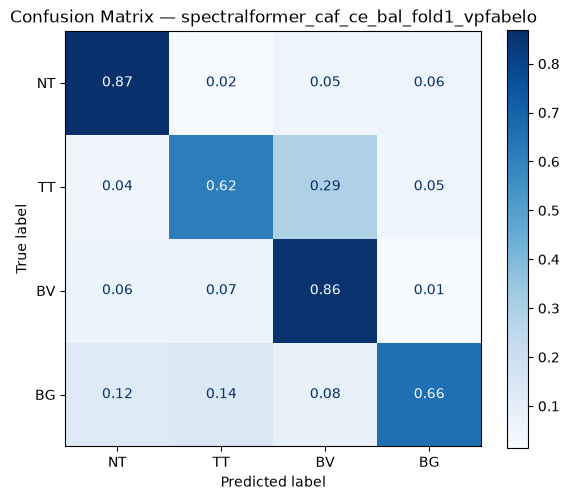

                    precision    recall  f1-score   support

Normal Tissue (NT)     0.8782    0.8698    0.8740    108722
Tumour Tissue (TT)     0.3362    0.6153    0.4348     13500
 Blood Vessel (BV)     0.6894    0.8584    0.7647     42005
   Background (BG)     0.8781    0.6599    0.7535     82318

          accuracy                         0.7838    246545
         macro avg     0.6955    0.7509    0.7068    246545
      weighted avg     0.8163    0.7838    0.7911    246545

  Saved → ../results/spectralformer_caf_ce_bal_fold1_vpfabelo_test_metrics.npy

────────────────────────────────────────────────────────────
  Evaluating : spectralformer_caf_ce_bal_fold2_vpfabelo
  Test images: 15
────────────────────────────────────────────────────────────


/Users/joshua/Repositories/brain-vision/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)



═══════════════════════════════════════════════════════════════════════════
  TEST RESULTS — spectralformer_caf_ce_bal_fold2_vpfabelo
═══════════════════════════════════════════════════════════════════════════
  Overall Accuracy (OA)      : 0.8196
  Macro F1  (all classes)    : 0.7557
  Macro F1  (no BG)          : 0.7490  ← Fabelo benchmark metric
  Macro Dice (all classes)   : 0.7557
  Macro Dice (no BG)         : 0.7490

  Class                      Sensitivity  Specificity     Dice       F1
  ────────────────────────────────────────────────────────────────────
  Normal Tissue (NT)              0.8586       0.9539   0.8958   0.8958
  Tumour Tissue (TT)              0.6696       0.9454   0.5128   0.5128  ← clinical priority
  Blood Vessel (BV)               0.9324       0.9400   0.8383   0.8383
  Background (BG)                 0.7351       0.9200   0.7759   0.7759
  ────────────────────────────────────────────────────────────────────
  Mean                            0.7989       0

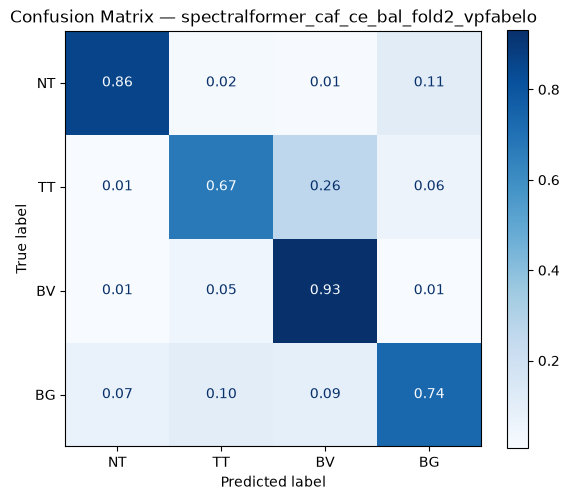

                    precision    recall  f1-score   support

Normal Tissue (NT)     0.9363    0.8586    0.8958    108722
Tumour Tissue (TT)     0.4155    0.6696    0.5128     13500
 Blood Vessel (BV)     0.7614    0.9324    0.8383     42005
   Background (BG)     0.8216    0.7351    0.7759     82318

          accuracy                         0.8196    246545
         macro avg     0.7337    0.7989    0.7557    246545
      weighted avg     0.8397    0.8196    0.8250    246545

  Saved → ../results/spectralformer_caf_ce_bal_fold2_vpfabelo_test_metrics.npy

────────────────────────────────────────────────────────────
  Evaluating : spectralformer_caf_ce_bal_fold3_vpfabelo
  Test images: 15
────────────────────────────────────────────────────────────


/Users/joshua/Repositories/brain-vision/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)



═══════════════════════════════════════════════════════════════════════════
  TEST RESULTS — spectralformer_caf_ce_bal_fold3_vpfabelo
═══════════════════════════════════════════════════════════════════════════
  Overall Accuracy (OA)      : 0.7678
  Macro F1  (all classes)    : 0.6847
  Macro F1  (no BG)          : 0.6848  ← Fabelo benchmark metric
  Macro Dice (all classes)   : 0.6847
  Macro Dice (no BG)         : 0.6848

  Class                      Sensitivity  Specificity     Dice       F1
  ────────────────────────────────────────────────────────────────────
  Normal Tissue (NT)              0.8771       0.9399   0.8981   0.8981
  Tumour Tissue (TT)              0.6407       0.8839   0.3515   0.3515  ← clinical priority
  Blood Vessel (BV)               0.9639       0.9115   0.8050   0.8050
  Background (BG)                 0.5442       0.9769   0.6845   0.6845
  ────────────────────────────────────────────────────────────────────
  Mean                            0.7565       0

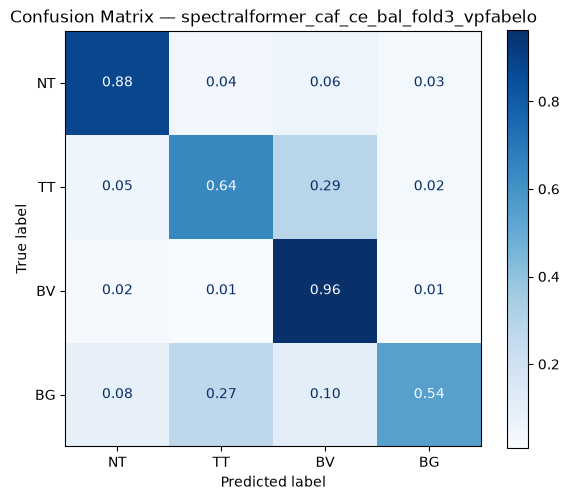

                    precision    recall  f1-score   support

Normal Tissue (NT)     0.9200    0.8771    0.8981    108722
Tumour Tissue (TT)     0.2422    0.6407    0.3515     13500
 Blood Vessel (BV)     0.6910    0.9639    0.8050     42005
   Background (BG)     0.9221    0.5442    0.6845     82318

          accuracy                         0.7678    246545
         macro avg     0.6938    0.7565    0.6847    246545
      weighted avg     0.8446    0.7678    0.7810    246545

  Saved → ../results/spectralformer_caf_ce_bal_fold3_vpfabelo_test_metrics.npy

────────────────────────────────────────────────────────────
  Evaluating : spectralformer_caf_ce_bal_fold4_vpfabelo
  Test images: 15
────────────────────────────────────────────────────────────


/Users/joshua/Repositories/brain-vision/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)



═══════════════════════════════════════════════════════════════════════════
  TEST RESULTS — spectralformer_caf_ce_bal_fold4_vpfabelo
═══════════════════════════════════════════════════════════════════════════
  Overall Accuracy (OA)      : 0.7909
  Macro F1  (all classes)    : 0.7142
  Macro F1  (no BG)          : 0.6997  ← Fabelo benchmark metric
  Macro Dice (all classes)   : 0.7142
  Macro Dice (no BG)         : 0.6997

  Class                      Sensitivity  Specificity     Dice       F1
  ────────────────────────────────────────────────────────────────────
  Normal Tissue (NT)              0.8629       0.9382   0.8890   0.8890
  Tumour Tissue (TT)              0.6497       0.9231   0.4366   0.4366  ← clinical priority
  Blood Vessel (BV)               0.8941       0.9143   0.7736   0.7736
  Background (BG)                 0.6663       0.9538   0.7578   0.7578
  ────────────────────────────────────────────────────────────────────
  Mean                            0.7682       0

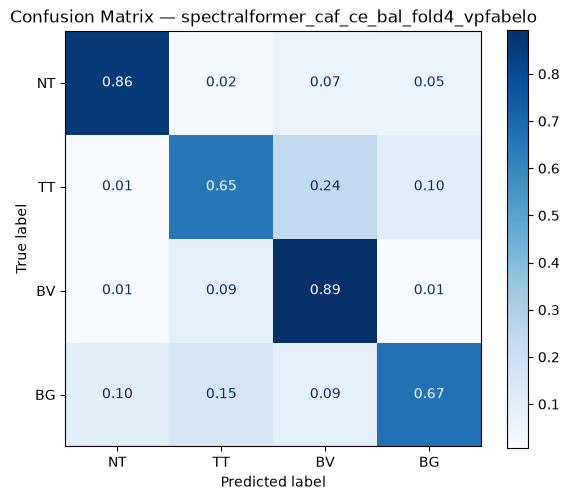

                    precision    recall  f1-score   support

Normal Tissue (NT)     0.9167    0.8629    0.8890    108722
Tumour Tissue (TT)     0.3287    0.6497    0.4366     13500
 Blood Vessel (BV)     0.6818    0.8941    0.7736     42005
   Background (BG)     0.8784    0.6663    0.7578     82318

          accuracy                         0.7909    246545
         macro avg     0.7014    0.7682    0.7142    246545
      weighted avg     0.8317    0.7909    0.8008    246545

  Saved → ../results/spectralformer_caf_ce_bal_fold4_vpfabelo_test_metrics.npy

────────────────────────────────────────────────────────────
  Evaluating : spectralformer_caf_ce_bal_fold5_vpfabelo
  Test images: 15
────────────────────────────────────────────────────────────


/Users/joshua/Repositories/brain-vision/.venv/lib/python3.14/site-packages/torch/utils/data/dataloader.py:759: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)



═══════════════════════════════════════════════════════════════════════════
  TEST RESULTS — spectralformer_caf_ce_bal_fold5_vpfabelo
═══════════════════════════════════════════════════════════════════════════
  Overall Accuracy (OA)      : 0.7764
  Macro F1  (all classes)    : 0.6976
  Macro F1  (no BG)          : 0.6878  ← Fabelo benchmark metric
  Macro Dice (all classes)   : 0.6976
  Macro Dice (no BG)         : 0.6878

  Class                      Sensitivity  Specificity     Dice       F1
  ────────────────────────────────────────────────────────────────────
  Normal Tissue (NT)              0.8806       0.9101   0.8830   0.8830
  Tumour Tissue (TT)              0.6400       0.9204   0.4246   0.4246  ← clinical priority
  Blood Vessel (BV)               0.8879       0.9052   0.7558   0.7558
  Background (BG)                 0.6044       0.9709   0.7271   0.7271
  ────────────────────────────────────────────────────────────────────
  Mean                            0.7532       0

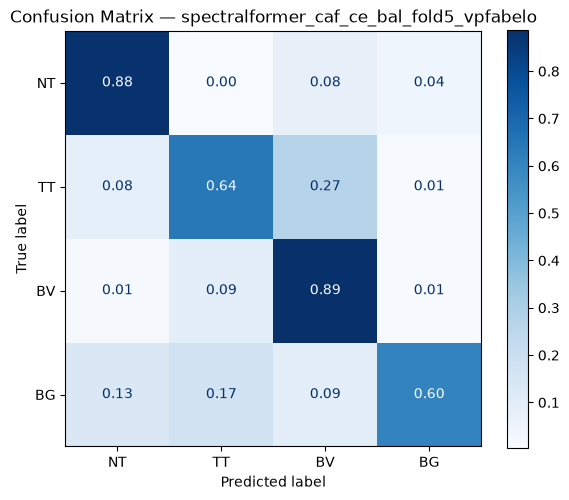

                    precision    recall  f1-score   support

Normal Tissue (NT)     0.8854    0.8806    0.8830    108722
Tumour Tissue (TT)     0.3177    0.6400    0.4246     13500
 Blood Vessel (BV)     0.6579    0.8879    0.7558     42005
   Background (BG)     0.9124    0.6044    0.7271     82318

          accuracy                         0.7764    246545
         macro avg     0.6934    0.7532    0.6976    246545
      weighted avg     0.8246    0.7764    0.7842    246545

  Saved → ../results/spectralformer_caf_ce_bal_fold5_vpfabelo_test_metrics.npy


In [31]:
Path(RESULTS_DIR).mkdir(parents=True, exist_ok=True)

all_metrics = []
for split in all_splits:
    metrics = evaluate_fold(split)
    if metrics:
        all_metrics.append(metrics)

In [32]:
aggregate = aggregate_fold_metrics(all_metrics)

In [33]:
print_aggregate(aggregate, model=MODEL, loss_fn=LOSS_FN, strategy=STRATEGY)


═════════════════════════════════════════════════════════════════
  AGGREGATE — SpectralFormer × CE × vp_fabelo
  5 folds
═════════════════════════════════════════════════════════════════
  Macro F1  (all)    : 70.7 ± 2.4%
  Macro F1  (no BG)  : 69.1 ± 2.4%  ← vs Fabelo 70.2 ± 7.9%
  Macro Dice (all)   : 70.7 ± 2.4%
  Macro Dice (no BG) : 69.1 ± 2.4%
  OA                 : 78.4 ± 1.8%

  Class      Sens     ±     Spec     ±      Dice     ±
  ───────────────────────────────────────────────────────
  NT        87.0%   ± 0.8%     93.8%   ± 1.9%     88.9%   ± 0.9%
  TT        64.1%   ± 1.7%     92.3%   ± 2.0%     43.5%   ± 5.1%  ← clinical priority
  BV        89.4%   ± 3.7%     91.4%   ± 1.2%     77.4%   ± 3.0%
  BG        66.0%   ± 6.4%     95.4%   ± 2.0%     75.4%   ± 3.2%

  Per-fold F1 (no BG)  : ['69.1%', '74.9%', '68.5%', '70.0%', '68.8%']
  Per-fold Dice (no BG): ['69.1%', '74.9%', '68.5%', '70.0%', '68.8%']
